In [8]:
import numpy as np 
import os
import pandas as pd

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import os
import argparse
import yaml
from matplotlib import rcParams
import seaborn as sns
from scipy import stats

# Set publication-quality matplotlib parameters
def setup_publication_style():
    """Set up matplotlib for publication-quality plots"""
    rcParams.update({
        'figure.figsize': (8, 5),
        'font.size': 12,
        'axes.labelsize': 14,
        'axes.titlesize': 16,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 11,
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'text.usetex': False,  # Set to True if you have LaTeX installed
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
        'axes.axisbelow': True,
        'lines.linewidth': 2.5,
        'lines.markersize': 8,
        'errorbar.capsize': 3,
        'legend.frameon': True,
        'legend.fancybox': True,
        'legend.shadow': True,
        'legend.framealpha': 0.9
    })

def smooth_curve(x, y, window_size=3):
    """Apply smoothing to reduce noise in curves"""
    if len(y) < window_size:
        return x, y
    
    # Simple moving average
    smoothed_y = np.convolve(y, np.ones(window_size)/window_size, mode='valid')
    smoothed_x = x[window_size-1:]
    
    return smoothed_x, smoothed_y

def plot_with_confidence_bands(x, y, std, label, color, alpha_fill=0.15, smooth=True):
    """Plot curves with confidence bands and optional smoothing"""
    
    if smooth and len(x) > 3:
        # Smooth the main curve
        x_smooth, y_smooth = smooth_curve(x, y)
        # Also smooth the confidence bands
        _, upper_smooth = smooth_curve(x, y + std)
        _, lower_smooth = smooth_curve(x, y - std)
        
        # Plot smoothed curve
        plt.plot(x_smooth, y_smooth, label=label, color=color, linewidth=2.5, 
                marker='o', markersize=6, markerfacecolor='white', markeredgecolor=color, 
                markeredgewidth=2)
        
        # Add confidence band
        plt.fill_between(x_smooth, lower_smooth, upper_smooth, 
                        color=color, alpha=alpha_fill, interpolate=True)
        
        # Add error bars at original points for clarity
        plt.errorbar(x, y, yerr=std, fmt='none', color=color, alpha=0.7, 
                    capsize=3, capthick=1.5, elinewidth=1.5)
    else:
        # Plot original curve with error bars
        plt.errorbar(x, y, yerr=std, label=label, color=color, 
                    linewidth=2.5, marker='o', markersize=6, capsize=3,
                    markerfacecolor='white', markeredgecolor=color, markeredgewidth=2)
        
        # Add confidence band
        plt.fill_between(x, y - std, y + std, color=color, alpha=alpha_fill)

def main():
    parser = argparse.ArgumentParser(description='Create publication-quality unlearning evaluation plots')
    parser.add_argument('--cfg_file', default='configs/larger_bs_no_weight_decay_2_layers_spectral_norm_waterbird.yaml')
    parser.add_argument('--smooth', action='store_true', help='Apply smoothing to curves')
    parser.add_argument('--style', choices=['default', 'seaborn', 'bmh'], default='default',
                       help='Plot style theme')
    args = parser.parse_args()

    # Set up publication style
    setup_publication_style()
    
    # Apply additional style if requested
    if args.style == 'seaborn':
        sns.set_style("whitegrid")
        sns.set_palette("husl")
    elif args.style == 'bmh':
        plt.style.use('bmh')

    with open(args.cfg_file, 'r') as f:
        config = yaml.safe_load(f)
    
    # Create figure with better proportions
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    n_points = [1000,2000,4000, 4795]
    checkpoints = [1, 5, 10, 15,20]
    same_fraction = False
    lr = config['training']['lr']
    l = config['training']['n_layers']
    spectral_norm = config['training']['spectral_norm']
    plot_estimates = False
    layer_norm = config['training']['layer_norm']
    add = config['set_up']['suffix']
    
    if same_fraction:
        n_points = [10000, 15000, 20000]
    
    data_path = os.path.join('results', add)
    print(f"Data path: {data_path}")
    
    # Define a professional color palette
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    if plot_estimates:
        # Estimates plotting section (improved)
        for i, n in enumerate(n_points):
            try:
                estimates_path = os.path.join(data_path, f'{n}public_points/test_spectral_norm{spectral_norm}layer_norm{layer_norm}estimates_checkpoint_0_lr{lr}len{l}.npy')
                std_path = os.path.join(data_path, f'{n}public_points/test_spectral_norm{spectral_norm}layer_norm{layer_norm}estimates_std_checkpoint_0_lr{lr}len{l}.npy')
                
                estimates = np.load(estimates_path)
                std = np.load(std_path)
                x_vals = np.arange(len(estimates))
                n_private_points = 22000 - n
                plot_with_confidence_bands(x_vals, estimates, std, 
                                         f'{n//1000}K public points, {n_private_points//1000}K private points', 
                                         colors[i % len(colors)], 
                                         smooth=args.smooth)
                
            except FileNotFoundError as e:
                print(f"Warning: Could not load data for {n} points: {e}")
                continue
        
        plt.xlabel('Iteration', fontweight='bold')
        plt.ylabel('Renyi Divergence Estimate', fontweight='bold')
        plt.title('Renyi Divergence Estimation During Unlearning', fontweight='bold', pad=20)
        
    else:
        # Main results plotting (improved)
        max_renyi = -np.inf
        min_renyi = np.inf
        
        for i, n in enumerate(n_points):
            print(f'Processing {n} public points...')
            renyi_vals = []
            stds = []
            base_path = os.path.join(data_path, f'{n}_public_points/')
            actual_checkpoints = []
            
            if os.path.exists(base_path):
                for checkpoint in checkpoints:
                    renyi_path = os.path.join(base_path, f'test_spectral_norm_{spectral_norm}layer_norm{layer_norm}renyi_result_checkpoint{checkpoint}lr{lr}len{l}.npy')
                    last_estimate_path = os.path.join(base_path,f'test_spectral_norm_{spectral_norm}layer_norm{layer_norm}all_estimates_checkpoint{checkpoint}lr{lr}len{l}.npy')
                    if os.path.exists(renyi_path):
                        try:
                            actual_checkpoints.append(checkpoint)
                            renyi_val = np.load(renyi_path, allow_pickle=True).item()
                            renyi_valu = np.load(last_estimate_path, allow_pickle=True)[-1].mean().item()
                            #renyi_vals.append(renyi_val['renyi_val'])
                            renyi_vals.append(renyi_valu)
                            stds.append(renyi_val['std'])
                            #stds.append(0)  # Placeholder if std not available
                            #print(f'  Checkpoint {checkpoint}: Renyi = {renyi_val["renyi_val"]:.4f} ± {renyi_val["std"]:.4f}')
                            print(f'  Checkpoint {checkpoint}: Renyi = {renyi_valu:.4f} ± {renyi_val["std"]:.4f}')
                        except Exception as e:
                            print(f"  Warning: Could not load checkpoint {checkpoint}: {e}")
                            continue
                
                if len(renyi_vals) > 0:
                    renyi_vals = np.array(renyi_vals)
                    stds = np.array(stds)
                    actual_checkpoints = np.array(actual_checkpoints)
                    
                    # Track min/max for y-axis scaling
                    max_renyi = max(max_renyi, np.max(renyi_vals + stds))
                    min_renyi = min(min_renyi, np.min(renyi_vals - stds))
                    n_private_points = 22000 - n
                    # Plot with improved styling
                    plot_with_confidence_bands(actual_checkpoints, renyi_vals, stds,
                                             f'{n//1000}K public points, {n_private_points//1000}K private points',
                                             colors[i % len(colors)],
                                             smooth=args.smooth)
                else:
                    print(f'  No valid data found for {n} public points')
            else:
                print(f'  Path does not exist: {base_path}')
        
        # Customize axes and labels
        plt.xlabel('Unlearning Iteration (K)', fontweight='bold')
        plt.ylabel(r'$\widehat{D_{\alpha}(\pi_R^{T+K}\|\pi_U^{K})}$', fontweight='bold')

        # Improve y-axis scaling
        if max_renyi > min_renyi:
            y_margin = (max_renyi - min_renyi) * 0.1
            plt.ylim(min_renyi - y_margin, max_renyi + y_margin)
    
    # Improve legend
    legend = plt.legend(loc='best', fancybox=True, shadow=True, ncol=1)
    legend.get_frame().set_alpha(0.9)
    
    # Add subtle grid
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Tight layout with padding
    plt.tight_layout(pad=2.0)
    
    # Save with high DPI for publication
    output_path = os.path.join(data_path, 'renyi_estimation_publication.pdf')
    plt.savefig(output_path, dpi=300, bbox_inches='tight', 
               facecolor='white', edgecolor='none')
    plt.savefig(output_path.replace('.pdf', '.png'), dpi=300, bbox_inches='tight',
               facecolor='white', edgecolor='none')
    
    print(f"Publication-quality plot saved to: {output_path}")
    plt.show()

main()

usage: ipykernel_launcher.py [-h] [--cfg_file CFG_FILE] [--smooth]
                             [--style {default,seaborn,bmh}]
ipykernel_launcher.py: error: unrecognized arguments: --f=/run/user/1564/jupyter/runtime/kernel-v3dba3ed054f87d94dfb16954058279912b2008ec4.json


SystemExit: 2

/home/lamsade/msammut/error_detection/error-estimation/myenv/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3675: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# def read_table(
#     data_name=None,
#     model_name=None,
#     method_name=None,
#     r=None,
#     seed_split=None,
#     n_epochs=None,
#     transform=None,
#     hyperparam=True,
#     expe_folder=None,
#     n_folds=None,
#     space=None,
#     distance=None,
#     clustering_name=None,
#     normalize_gini=None,
#     ):

#     if expe_folder is None:

#         root = f"../../results/{data_name}_{model_name}_r-{r}_seed-split-{seed_split}"
#         if method_name in ["clustering", "metric_learning", "random_forest"]:
#             root += f"/transform-{transform}_n-epoch{n_epochs}_n-folds{n_folds}_{space}"
#             if method_name == "clustering":
#                 if distance is not None:
#                     root += f"_distance-{distance}"
#                 if clustering_name != "soft-kmeans":
#                     root += f"_{clustering_name}"
#                 # root += f"_probweights"
#         elif method_name == "gini":
#             root += f"/transform-{transform}_normalize-{normalize_gini}"
#         else:
#             root += f"/transform-{transform}"
#         expe_folder = root + f"_{method_name}"

#     if hyperparam:
#         df = pd.read_csv(os.path.join(expe_folder, "hyperparams_results.csv"))
#     else:
#         df = pd.read_csv(os.path.join(expe_folder, "all_results.csv"))
    
#     return df


# def get_grid_search(df):
#     method_name = df['method_name'].iloc[0]
#     cols = [col for col in df.columns if col.startswith(f'{method_name}_')]
#     unique_combinations = df[cols].drop_duplicates()
#     return unique_combinations

# def sort_values(df, metrics=["fpr_train"]):

#     method_name = df['method_name'].iloc[0]
#     cols = [col for col in df.columns if col.startswith(f'{method_name}_')]
#     ascending = [True if metric in ["fpr_train", "fpr_test", "aurc_train", "aurc_test"] else False for metric in metrics]
#     sorted_df = df.sort_values(by=metrics, ascending=ascending)
#     return sorted_df[cols + metrics]



# ImageNet

In [3]:
# def read_table(
#     data_name=None,
#     model_name=None,
#     method_name=None,
#     r=None,
#     seed_split=None,
#     n_epochs=None,
#     transform=None,
#     hyperparam=True,
#     expe_folder=None,
#     n_folds=None,
#     space=None,
#     distance=None,
#     clustering_name=None,
#     normalize_gini=None,
#     num=None
#     ):

#     if expe_folder is None:

#         root = f"../../results/{data_name}_{model_name}_r-{r}_seed-split-{seed_split}"
#         if method_name in ["clustering", "metric_learning", "random_forest"]:
#             root += f"/transform-{transform}_n-epoch{n_epochs}_n-folds{n_folds}_{space}"
#             if method_name == "clustering":
#                 if distance is not None:
#                     root += f"_distance-{distance}"
#                 if clustering_name != "soft-kmeans":
#                     root += f"_{clustering_name}"
#                 # root += f"_probweights"
#         elif method_name == "gini":
#             root += f"/transform-{transform}_normalize-{normalize_gini}"
#         else:
#             root += f"/transform-{transform}"
#         expe_folder = root + f"_{method_name}"

    
#     if hyperparam:
#         expe_file = os.path.join(expe_folder, "hyperparams_results.csv")
#     #     df = pd.read_csv(os.path.join(expe_folder, "hyperparams_results.csv"))
#     else:
#         expe_file = os.path.join(expe_folder, "results_opt_fpr.csv")
#         # df = pd.read_csv(os.path.join(expe_folder, "all_results.csv"))
#     if num is not None:
#         expe_file = expe_file.replace(".csv", f"_{num}.csv")
#     df = pd.read_csv(expe_file)
#     return df

In [20]:
data_name = "imagenet"
r= 0.7
model_name = "timm_vit_base16"  # resnet34, densenet121, vit_tiny16, vit_base16, mlp_synth_dim-10_classes-7
seed_split = 9
transform = "test"
method_name = "clustering"
n_epochs = 1
space = "probits"
clustering_name = "soft-kmeans_torch"
n_folds = 3
n_inits = 10
bound = "bernstein"
init = "kmeans"

root = f"../../test_ce_results/{data_name}_{model_name}_r-{r}_seed-split-{seed_split}"
expe_folder = root + f"/transform-{transform}_n-epoch{n_epochs}_n-folds{n_folds}_{space}_{clustering_name}_{bound}_n-init-{n_inits}_{init}_clustering"
num = 1
df = read_table(
    expe_folder=expe_folder,
    hyperparam=True,
    # num=1,
    ).sort_values("fpr_val_cross")
print("length of df:", len(df))
# [["clustering.n_clusters", "clustering.temperature", "fpr_val_cross", "fpr_val_cross_std"]]
df[["clustering.n_clusters", "clustering.temperature", "fpr_val_cross", "fpr_val_cross_std"]].head(10)


length of df: 1000


,clustering.n_clusters,clustering.temperature,fpr_val_cross,fpr_val_cross_std
388,190,1.8,0.430538,0.001982
128,140,1.2,0.433263,0.016765
873,265,1.7,0.433716,0.006393
883,265,1.8,0.435324,0.010025
872,260,1.7,0.435707,0.003610
112,110,1.1,0.436232,0.011583
880,250,1.8,0.436441,0.012194
684,220,1.8,0.437140,0.008138
696,230,1.9,0.437140,0.018776
882,260,1.8,0.437350,0.007649


In [30]:
df_analysis.sort_values("clustering.n_clusters")

,clustering.n_clusters,fpr_val_cross,fpr_val_cross_std
180,100,0.465435,0.016369
181,105,0.478324,0.012622
182,110,0.465784,0.004271
183,115,0.468789,0.009606
184,120,0.467112,0.019188
185,125,0.459531,0.003305
186,130,0.463408,0.006333
187,135,0.470045,0.011124
188,140,0.457191,0.005217
189,145,0.455199,0.020268


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple, List

def plot_metric_curve(
    df,
    metric: str,
    fixed: str = "temperature",            # "temperature" or "n_clusters"
    fixed_value: Optional[float] = None,   # if None: auto-select the best
    min_value: Optional[float] = None,     # filter free axis (>=)
    max_value: Optional[float] = None,     # filter free axis (<=)
    metric_col_suffix: str = "_val_cross",
    std_col_suffix: str = "_val_cross_std",
    temp_col: str = "clustering.temperature",
    k_col: str = "clustering.n_clusters",
    ascending: Optional[bool] = None,      # None -> infer from metric
    title_prefix: Optional[str] = None,
    ax: Optional[plt.Axes] = None,
    fix_tol: float = 1e-10,                # tolerance for float equality on fixed temperature
    print_duplicates: bool = False,        # print rows before raising on duplicates
) -> Tuple[float, plt.Axes]:
    """
    Plot `metric` vs the free hyperparameter with a ±std band.
    Strict mode: raises if there are duplicate x-values after fixing one hyperparameter.
    Column names are auto-resolved between dot and underscore variants.
    """

    import pandas as pd

    def _resolve_col(df, preferred: str, alts: Optional[List[str]] = None) -> str:
        """Return the first existing column among preferred and alternatives.
        Also tries dot<->underscore swapped variant of the preferred name."""
        candidates = [preferred]
        # dot <-> underscore swap for the preferred
        if "." in preferred:
            candidates.append(preferred.replace(".", "_"))
        if "_" in preferred:
            candidates.append(preferred.replace("_", "."))
        # user-provided alternatives
        if alts:
            candidates += alts
            # also add swapped versions of alts
            for a in list(alts):
                if "." in a:
                    candidates.append(a.replace(".", "_"))
                if "_" in a:
                    candidates.append(a.replace("_", "."))
        for c in candidates:
            if c in df.columns:
                return c
        raise KeyError(f"None of these columns found: {candidates}")

    # Resolve columns (supports both dotted and underscored styles)
    temp_col = _resolve_col(df, temp_col, alts=["temperature", "temp", "clustering_temperature"])
    k_col    = _resolve_col(df, k_col,    alts=["n_clusters", "k", "clustering_n_clusters"])

    mean_col = f"{metric}{metric_col_suffix}"
    std_col  = f"{metric}{std_col_suffix}"
    for c in (mean_col, std_col):
        if c not in df.columns:
            raise KeyError(f"Required metric column '{c}' not found in df.columns")

    if ascending is None:
        lower_is_better = {"fpr", "aurc", "err", "nll", "loss", "brier", "ece"}
        ascending = metric.lower() in lower_is_better  # True => minimize

    if fixed not in {"temperature", "n_clusters"}:
        raise ValueError("`fixed` must be 'temperature' or 'n_clusters'.")

    # Determine which column is fixed and which is the x-axis
    if fixed == "temperature":
        fixed_col = temp_col
        x_col     = k_col
        fixed_name = "temperature"
        free_name  = "Number of clusters"
    else:
        fixed_col = k_col
        x_col     = temp_col
        fixed_name = "number of clusters"
        free_name  = "Temperature"

    # Keep only necessary columns and drop NaNs
    keep = [temp_col, k_col, mean_col, std_col]
    df_clean = df[keep].dropna()

    # Auto-select best fixed value if not provided
    if fixed_value is None:
        g = df_clean.groupby(fixed_col, as_index=False)[mean_col].mean()
        if g.empty:
            raise ValueError("No data available to choose a best value for the fixed hyperparameter.")
        g = g.sort_values(mean_col, ascending=ascending)
        fixed_value = g.iloc[0][fixed_col]

    # Slice at the fixed value (use tolerance for float temperatures)
    if fixed == "temperature":
        vals = df_clean[fixed_col].to_numpy()
        mask = np.isclose(vals, fixed_value, rtol=0.0, atol=fix_tol)
        df_sel = df_clean.loc[mask].copy()
    else:
        df_sel = df_clean.loc[df_clean[fixed_col] == fixed_value].copy()

    if df_sel.empty:
        raise ValueError(
            f"No rows after fixing {fixed_col}={fixed_value}. "
            f"(Consider relaxing fix_tol={fix_tol} if fixing temperature.)"
        )

    # Optional filtering on the free axis (after slicing)
    if min_value is not None:
        df_sel = df_sel[df_sel[x_col] >= min_value]
    if max_value is not None:
        df_sel = df_sel[df_sel[x_col] <= max_value]
    if df_sel.empty:
        raise ValueError("All rows were filtered out by min_value/max_value on the free axis.")

    # Strict duplicate check on x
    vc = df_sel[x_col].value_counts().sort_index()
    dup = vc[vc > 1]
    if not dup.empty:
        if print_duplicates:
            print("Duplicate x-values and counts:", dict(dup))
            print("\nRows causing duplicates:")
            with pd.option_context("display.max_rows", None, "display.width", 160):
                print(df_sel[df_sel[x_col].isin(dup.index)]
                      .sort_values([x_col, temp_col, k_col, mean_col])
                      .to_string(index=False))
        raise ValueError(
            f"Duplicate x-values detected for {x_col} after fixing {fixed_col}={fixed_value}: "
            f"{dict(dup)}. Resolve duplicates upstream."
        )

    # Sort and make arrays
    df_plot = df_sel.sort_values(x_col)
    x = df_plot[x_col].to_numpy()
    y = df_plot[mean_col].to_numpy()
    s = df_plot[std_col].to_numpy()

    # Sanity checks
    if np.any(~np.isfinite(x) | ~np.isfinite(y) | ~np.isfinite(s)):
        raise ValueError("Non-finite values in x, mean, or std columns.")
    s = np.clip(s, 0.0, None)  # forbid negative std

    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(x, y, marker="o")
    ax.fill_between(x, y - s, y + s, alpha=0.20, linewidth=0)

    if title_prefix is None:
        title_prefix = f"{metric.upper()} vs {free_name}"
    ax.set_title(
        f"{title_prefix}\nBest {fixed_name}: "
        f"{fixed_value:.6g}" if isinstance(fixed_value, (int, float, np.floating))
        else f"{title_prefix}\nBest {fixed_name}: {fixed_value}"
    )
    ax.set_xlabel(free_name)
    ax.set_ylabel(f"{metric.upper()} on validation set")
    ax.grid(True)

    return (float(fixed_value) if isinstance(fixed_value, (int, float, np.floating)) else fixed_value), ax


In [11]:
import os
import re
import glob
import pandas as pd

def read_table(
    data_name=None,
    model_name=None,
    method_name=None,
    r=None,
    seed_split=None,
    n_epochs=None,
    transform=None,
    hyperparam=True,
    expe_folder=None,
    n_folds=None,
    space=None,
    distance=None,
    clustering_name=None,
    normalize_gini=None,
    num=None,
):
    """
    Load and concatenate all matching result CSVs from `expe_folder`.

    Matching patterns:
      - hyperparam=True  -> 'hyperparams_results*.csv'
      - hyperparam=False -> 'results_opt_fpr*.csv'

    Adds:
      - file_num (int): 0 for base file, i for '_i' files
      - source_file (str): basename of the CSV

    If `num` is provided, only that specific file is read (and annotated).
    """

    # ----- Build experiment folder if not provided -----
    if expe_folder is None:
        if any(v is None for v in [data_name, model_name, method_name, r, seed_split]):
            raise ValueError("When expe_folder is None, provide data_name, model_name, method_name, r, seed_split.")
        root = f"../../results/{data_name}_{model_name}_r-{r}_seed-split-{seed_split}"
        if method_name in ["clustering", "metric_learning", "random_forest"]:
            if any(v is None for v in [transform, n_epochs, n_folds, space]):
                raise ValueError("transform, n_epochs, n_folds, space required for these methods when expe_folder is None.")
            root += f"/transform-{transform}_n-epoch{n_epochs}_n-folds{n_folds}_{space}"
            if method_name == "clustering":
                if distance is not None:
                    root += f"_distance-{distance}"
                if clustering_name != "soft-kmeans":
                    root += f"_{clustering_name}"
        elif method_name == "gini":
            if any(v is None for v in [transform, normalize_gini]):
                raise ValueError("transform and normalize_gini required for method 'gini' when expe_folder is None.")
            root += f"/transform-{transform}_normalize-{normalize_gini}"
        else:
            if transform is None:
                raise ValueError("transform is required when expe_folder is None.")
            root += f"/transform-{transform}"
        expe_folder = root + f"_{method_name}"

    base_name = "hyperparams_results" if hyperparam else "results_opt_fpr"
    rx = re.compile(rf"{re.escape(base_name)}(?:_(\d+))?\.csv$")

    # If `num` is specified, read that specific file only (annotated).
    if num is not None:
        # Allow num==0 or '' to mean base file (no suffix)
        fname = f"{base_name}.csv" if str(num) in ("", "0") else f"{base_name}_{num}.csv"
        target = os.path.join(expe_folder, fname)
        if not os.path.isfile(target):
            raise FileNotFoundError(f"No such file: {target}")
        df = pd.read_csv(target)
        # annotate
        m = rx.search(os.path.basename(target))
        file_num = int(m.group(1)) if (m and m.group(1) is not None) else 0
        df = df.copy()
        df["file_num"] = file_num
        df["source_file"] = os.path.basename(target)
        return df

    # Otherwise, gather *all* matching files.
    pattern = os.path.join(expe_folder, f"{base_name}*.csv")
    files = [f for f in glob.glob(pattern) if rx.search(os.path.basename(f))]

    if not files:
        raise FileNotFoundError(f"No matching files found with pattern: {pattern}")

    def sort_key(p):
        m = rx.search(os.path.basename(p))
        idx = m.group(1)
        return (0 if idx is None else 1, int(idx) if idx is not None else -1)

    files.sort(key=sort_key)

    dfs = []
    for fpath in files:
        try:
            df_i = pd.read_csv(fpath)
        except Exception as e:
            raise RuntimeError(f"Failed to read '{fpath}': {e}") from e

        m = rx.search(os.path.basename(fpath))
        file_num = int(m.group(1)) if (m and m.group(1) is not None) else 0

        df_i = df_i.copy()
        df_i["file_num"] = file_num
        df_i["source_file"] = os.path.basename(fpath)
        dfs.append(df_i)

    return pd.concat(dfs, axis=0, ignore_index=True)


## Base_VIT16

In [5]:
data_name = "imagenet"
r= 0.7
model_name = "timm_vit_base16"  # resnet34, densenet121, vit_tiny16, vit_base16, mlp_synth_dim-10_classes-7
seed_split = 9
transform = "test"
method_name = "clustering"
n_epochs = 1
space = "probits"
clustering_name = "soft-kmeans_torch"
n_folds = 3
n_inits = 10
init_method = "kmeans" #k-means++
bound = "bernstein"

root = f"../../test_ce_results/{data_name}_{model_name}_r-{r}_seed-split-{seed_split}"
expe_folder = root + f"/transform-{transform}_n-epoch{n_epochs}_n-folds{n_folds}_{space}_{clustering_name}_{bound}_n-init-{n_inits}_{init_method}_clustering"
# num = 1
df = read_table(
    expe_folder=expe_folder,
    hyperparam=True,
    )
print("length of df:", len(df))
print("number of duplicates:", df.drop(columns=["source_file"]).duplicated().sum())
print("unique n_clusters:", np.sort(df["clustering.n_clusters"].unique()))
print("unique temperature:", np.sort(df["clustering.temperature"].unique()))
print("unique files:", df["source_file"].unique())
metric = "fpr"
df.sort_values(f"{metric}_val_cross")[["clustering.n_clusters", "clustering.temperature", f"{metric}_val_cross", "file_num"]]

length of df: 940
number of duplicates: 0
unique n_clusters: [100 105 110 115 120 125 130 135 140 145 150 155 160 165 170 175 180 185
 190 195 200 205 210 215 220 225 230 235 240 245 250 255 260 265 270 275
 280 285 290 295 300 305 310 315 320 325 330 335 340 345 350 355 360 365
 370 375 380 385 390 395]
unique temperature: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8
 1.9]
unique files: ['hyperparams_results.csv' 'hyperparams_results_1.csv'
 'hyperparams_results_2.csv' 'hyperparams_results_3.csv'
 'hyperparams_results_4.csv' 'hyperparams_results_5.csv'
 'hyperparams_results_6.csv' 'hyperparams_results_7.csv'
 'hyperparams_results_8.csv' 'hyperparams_results_9.csv']


,clustering.n_clusters,clustering.temperature,fpr_val_cross,file_num
368,190,1.8,0.430538,3
118,140,1.2,0.433263,1
823,265,1.7,0.433716,8
833,265,1.8,0.435324,8
822,260,1.7,0.435707,8
...,...,...,...,...
936,380,0.9,1.000000,9
937,385,0.9,1.000000,9
938,390,0.9,1.000000,9
939,395,0.9,1.000000,9


Chosen temperature: 1.8


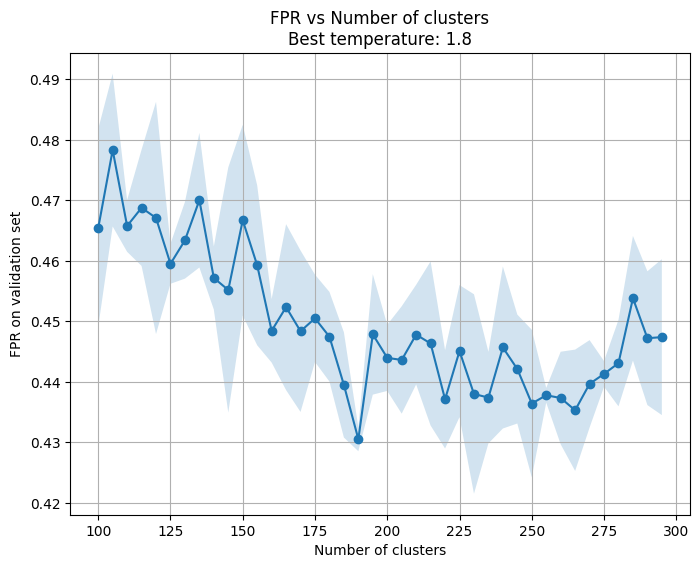

In [129]:
best_temp, ax = plot_metric_curve(
    df,
    metric="fpr",
    fixed="temperature",   # fix temperature, free axis = n_clusters
    fixed_value=None       # choose best temperature automatically (min FPR)
)
print("Chosen temperature:", best_temp)


In [97]:
ind = df.drop(columns=["source_file"]).duplicated(subset=["clustering.n_clusters", "clustering.temperature"], keep=False)
print("number of duplicates:", ind.sum())
df[ind][[
    "clustering.n_clusters", "clustering.temperature", "fpr_val_cross", "file_num", "source_file"]
    ].sort_values(["clustering.n_clusters", "clustering.temperature", "fpr_val_cross"]).head(10)

number of duplicates: 0


,clustering.n_clusters,clustering.temperature,fpr_val_cross,file_num,source_file


Chosen temperature: 190.0


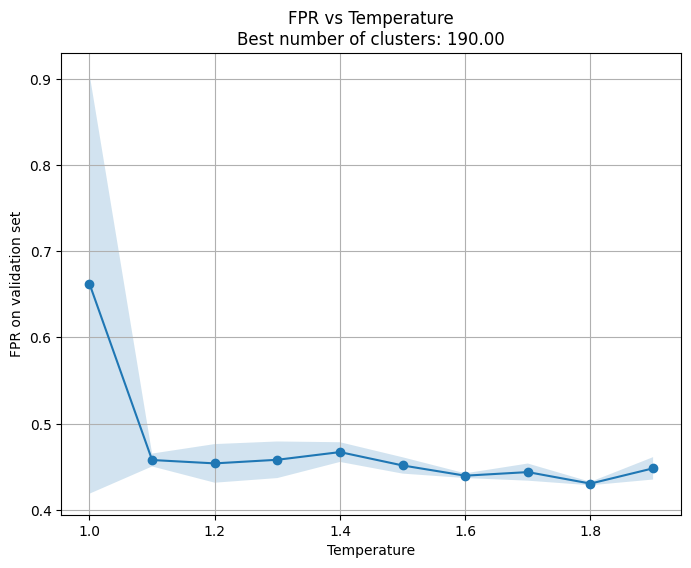

In [104]:
best_temp, ax = plot_metric_curve(
    df,
    metric="fpr",
    fixed="n_clusters",   # fix temperature, free axis = n_clusters
    fixed_value=None,       # choose best temperature automatically (min FPR)
    min_value=1)
print("Chosen temperature:", best_temp)


In [7]:
df = read_table(
    expe_folder=expe_folder,
    hyperparam=False,
    )
print("number of duplicates:", df.duplicated().sum())
print("unique n_clusters:", np.sort(df["clustering_n_clusters"].unique()))
print("unique temperature:", np.sort(df["clustering_temperature"].unique()))
cols_method = [col for col in df.columns if col.startswith(f'clustering_')]
val_metrics = [col for col in df.columns if col.endswith('_val')]
df.sort_values("fpr_val")[cols_method]
# + val_metrics + ["file_num"]


number of duplicates: 0
unique n_clusters: [125 140 165 190 200 220 250 265 300 350]
unique temperature: [0.1 1.  1.2 1.7 1.8]


,clustering_name,clustering_distance,clustering_n_clusters,clustering_reorder_embs,clustering_bound,clustering_seed,clustering_alpha,clustering_init_scheme,clustering_n_init,clustering_space,clustering_cov_type,clustering_temperature,clustering_pred_weight,clustering_normalize_gini,clustering_batch_size,clustering_reduction_name,clustering_reduction_dim,clustering_reduction_n_neighbors,clustering_reduction_seed
6,soft-kmeans_torch,NaN,220,True,bernstein,1,0.05,kmeans,10,probits,diag,1.8,NaN,False,2048,NaN,NaN,NaN,NaN
3,soft-kmeans_torch,NaN,190,True,bernstein,1,0.05,kmeans,10,probits,diag,1.8,NaN,False,2048,NaN,NaN,NaN,NaN
4,soft-kmeans_torch,NaN,200,True,bernstein,1,0.05,kmeans,10,probits,diag,1.0,NaN,False,2048,NaN,NaN,NaN,NaN
1,soft-kmeans_torch,NaN,140,True,bernstein,1,0.05,kmeans,10,probits,diag,1.2,NaN,False,2048,NaN,NaN,NaN,NaN
8,soft-kmeans_torch,NaN,265,True,bernstein,1,0.05,kmeans,10,probits,diag,1.7,NaN,False,2048,NaN,NaN,NaN,NaN
0,soft-kmeans_torch,NaN,125,True,bernstein,1,0.05,kmeans,10,probits,diag,1.0,NaN,False,2048,NaN,NaN,NaN,NaN
2,soft-kmeans_torch,NaN,165,True,bernstein,1,0.05,kmeans,10,probits,diag,1.0,NaN,False,2048,NaN,NaN,NaN,NaN
5,soft-kmeans_torch,NaN,250,True,bernstein,1,0.05,kmeans,10,probits,diag,0.1,NaN,False,2048,NaN,NaN,NaN,NaN
7,soft-kmeans_torch,NaN,300,True,bernstein,1,0.05,kmeans,10,probits,diag,0.1,NaN,False,2048,NaN,NaN,NaN,NaN
9,soft-kmeans_torch,NaN,350,True,bernstein,1,0.05,kmeans,10,probits,diag,0.1,NaN,False,2048,NaN,NaN,NaN,NaN


## Tiny_VIT16

In [12]:
data_name = "imagenet"
r= 0.7
model_name = "timm_vit_tiny16"  # resnet34, densenet121, vit_tiny16, vit_base16, mlp_synth_dim-10_classes-7
seed_split = 9
transform = "test"
method_name = "clustering"
n_epochs = 1
space = "probits"
clustering_name = "soft-kmeans_torch"
n_folds = 3
n_inits = 10
init_method = "k-means++"
bound = "bernstein"

root = f"../../test_ce_results/{data_name}_{model_name}_r-{r}_seed-split-{seed_split}"
expe_folder = root + f"/transform-{transform}_n-epoch{n_epochs}_n-folds{n_folds}_{space}_{clustering_name}_{bound}_n-init-{n_inits}_{init_method}_clustering"
num = 1
df = read_table(
    expe_folder=expe_folder,
    hyperparam=True,
    # num=8
    )
print("length of df:", len(df))
print("number of duplicates:", df.drop(columns=["source_file"]).duplicated().sum())
print("unique n_clusters:", np.sort(df["clustering.n_clusters"].unique()))
print("unique temperature:", np.sort(df["clustering.temperature"].unique()))
print("unique files:", df["source_file"].unique())
df.sort_values("fpr_val_cross")[["clustering.n_clusters", "clustering.temperature", "fpr_val_cross", "fpr_val_cross_std", "file_num"]]

length of df: 500
number of duplicates: 0
unique n_clusters: [100 105 110 115 120 125 130 135 140 145 150 155 160 165 170 175 180 185
 190 195 200 205 210 215 220 225 230 235 240 245 250 255 260 265 270 275
 280 285 290 295 300 305 310 315 320 325 330 335 340 345]
unique temperature: [1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9]
unique files: ['hyperparams_results.csv' 'hyperparams_results_1.csv'
 'hyperparams_results_2.csv' 'hyperparams_results_3.csv'
 'hyperparams_results_4.csv' 'hyperparams_results_5.csv'
 'hyperparams_results_6.csv' 'hyperparams_results_7.csv'
 'hyperparams_results_8.csv' 'hyperparams_results_9.csv']


,clustering.n_clusters,clustering.temperature,fpr_val_cross,fpr_val_cross_std,file_num
101,255,1.0,0.445704,0.010897,2
103,265,1.0,0.449455,0.007824,2
303,215,1.0,0.450099,0.002721,6
257,185,1.1,0.450894,0.008283,5
104,270,1.0,0.451084,0.007006,2
...,...,...,...,...,...
353,315,1.0,0.641869,0.253515,7
352,310,1.0,0.643536,0.252539,7
403,240,1.0,0.644635,0.252369,8
402,235,1.0,0.644786,0.251195,8


In [13]:
df = read_table(
    expe_folder=expe_folder,
    hyperparam=False,
    )
print("number of duplicates:", df.duplicated().sum())
print("unique n_clusters:", np.sort(df["clustering_n_clusters"].unique()))
print("unique temperature:", np.sort(df["clustering_temperature"].unique()))
cols_method = [col for col in df.columns if col.startswith(f'clustering_')]
val_metrics = [col for col in df.columns if col.endswith('_val')]
df.sort_values("fpr_val")[cols_method]
# + val_metrics + ["file_num"]


number of duplicates: 0
unique n_clusters: [100 135 165 180 185 215 245 255 275 280 305 345]
unique temperature: [1.  1.1 1.2]


,clustering_name,clustering_distance,clustering_n_clusters,clustering_reorder_embs,clustering_bound,clustering_seed,clustering_alpha,clustering_init_scheme,clustering_n_init,clustering_space,clustering_cov_type,clustering_temperature,clustering_pred_weight,clustering_normalize_gini,clustering_batch_size,clustering_reduction_name,clustering_reduction_dim,clustering_reduction_n_neighbors,clustering_reduction_seed
11,soft-kmeans_torch,NaN,180,True,bernstein,1,0.05,k-means++,10,probits,diag,1.0,NaN,False,2048,NaN,NaN,NaN,NaN
8,soft-kmeans_torch,NaN,245,True,bernstein,1,0.05,k-means++,10,probits,diag,1.1,NaN,False,2048,NaN,NaN,NaN,NaN
6,soft-kmeans_torch,NaN,215,True,bernstein,1,0.05,k-means++,10,probits,diag,1.0,NaN,False,2048,NaN,NaN,NaN,NaN
7,soft-kmeans_torch,NaN,305,True,bernstein,1,0.05,k-means++,10,probits,diag,1.1,NaN,False,2048,NaN,NaN,NaN,NaN
4,soft-kmeans_torch,NaN,275,True,bernstein,1,0.05,k-means++,10,probits,diag,1.1,NaN,False,2048,NaN,NaN,NaN,NaN
5,soft-kmeans_torch,NaN,185,True,bernstein,1,0.05,k-means++,10,probits,diag,1.1,NaN,False,2048,NaN,NaN,NaN,NaN
1,soft-kmeans_torch,NaN,135,True,bernstein,1,0.05,k-means++,10,probits,diag,1.2,NaN,False,2048,NaN,NaN,NaN,NaN
9,soft-kmeans_torch,NaN,345,True,bernstein,1,0.05,k-means++,10,probits,diag,1.0,NaN,False,2048,NaN,NaN,NaN,NaN
3,soft-kmeans_torch,NaN,165,True,bernstein,1,0.05,k-means++,10,probits,diag,1.1,NaN,False,2048,NaN,NaN,NaN,NaN
12,soft-kmeans_torch,NaN,280,True,bernstein,1,0.05,k-means++,10,probits,diag,1.0,NaN,False,2048,NaN,NaN,NaN,NaN


In [76]:
ind = df.drop(columns=["source_file"]).duplicated(subset=["clustering.n_clusters", "clustering.temperature"], keep=False)
print("number of duplicates:", ind.sum())
df[ind][[
    "clustering.n_clusters", "clustering.temperature", "fpr_val_cross", "file_num", "source_file"]
    ].sort_values(["clustering.n_clusters", "clustering.temperature", "fpr_val_cross"]).head(10)

number of duplicates: 0


,clustering.n_clusters,clustering.temperature,fpr_val_cross,file_num,source_file


In [123]:
best_temp, ax = plot_metric_curve(
    df,
    metric="fpr",
    fixed="temperature",   # fix temperature, free axis = n_clusters
    fixed_value=1.1       # choose best temperature automatically (min FPR)
)
print("Chosen temperature:", best_temp)


ValueError: No rows after fixing clustering_temperature=1.1.

Chosen temperature: 255.0


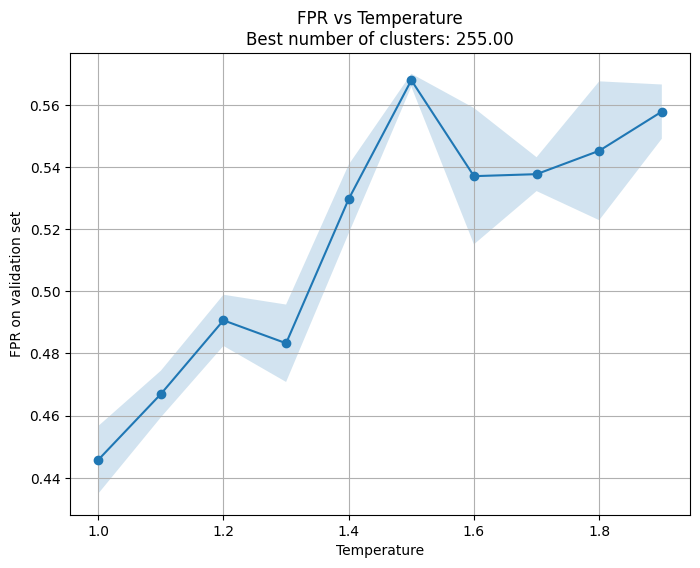

In [88]:
best_temp, ax = plot_metric_curve(
    df,
    metric="fpr",
    fixed="n_clusters",   # fix temperature, free axis = n_clusters
    fixed_value=None       # choose best temperature automatically (min FPR)
)
print("Chosen temperature:", best_temp)


In [35]:
df = read_table(
    expe_folder=expe_folder,
    hyperparam=False,
    )
print("number of duplicates:", df.duplicated().sum())
print("unique n_clusters:", np.sort(df["clustering_n_clusters"].unique()))
print("unique temperature:", np.sort(df["clustering_temperature"].unique()))
cols_method = [col for col in df.columns if col.startswith(f'clustering_')]
val_metrics = [col for col in df.columns if col.endswith('_val')]
df.sort_values("fpr_val")[cols_method + val_metrics + ["file_num"]]

number of duplicates: 0
unique n_clusters: [100 135 165 185 215 245 255 275 305 345]
unique temperature: [1.  1.1 1.2]


,clustering_name,clustering_distance,clustering_n_clusters,clustering_reorder_embs,clustering_bound,clustering_seed,clustering_alpha,clustering_init_scheme,clustering_n_init,clustering_space,...,clustering_reduction_seed,fpr_val,tpr_val,thr_val,roc_auc_val,model_acc_val,aurc_val,aupr_err_val,aupr_success_val,file_num
8,soft-kmeans_torch,NaN,245,True,bernstein,1,0.05,k-means++,10,probits,...,NaN,[0.47000706],[0.95005459],[0.13646013],[0.84816707],[0.24426667],[0.45564394],[0.58650714],[0.9416054],8
6,soft-kmeans_torch,NaN,215,True,bernstein,1,0.05,k-means++,10,probits,...,NaN,[0.47265349],[0.95032751],[0.12843239],[0.85180755],[0.24426667],[0.45935578],[0.59530625],[0.94276047],6
7,soft-kmeans_torch,NaN,305,True,bernstein,1,0.05,k-means++,10,probits,...,NaN,[0.47353564],[0.95169214],[0.15018751],[0.84507654],[0.24426667],[0.44933422],[0.57046706],[0.93950842],7
4,soft-kmeans_torch,NaN,275,True,bernstein,1,0.05,k-means++,10,probits,...,NaN,[0.47732886],[0.95305677],[0.14645082],[0.84667671],[0.24426667],[0.45282013],[0.57933585],[0.94100263],4
5,soft-kmeans_torch,NaN,185,True,bernstein,1,0.05,k-means++,10,probits,...,NaN,[0.48315102],[0.95114629],[0.12633117],[0.84884686],[0.24426667],[0.46069598],[0.60038042],[0.94182876],5
1,soft-kmeans_torch,NaN,135,True,bernstein,1,0.05,k-means++,10,probits,...,NaN,[0.48376853],[0.95251092],[0.18440959],[0.84916885],[0.24426667],[0.46467354],[0.61233564],[0.94233375],1
9,soft-kmeans_torch,NaN,345,True,bernstein,1,0.05,k-means++,10,probits,...,NaN,[0.48597389],[0.95496725],[0.12090512],[0.84634536],[0.24426667],[0.44785839],[0.56548906],[0.93851796],9
3,soft-kmeans_torch,NaN,165,True,bernstein,1,0.05,k-means++,10,probits,...,NaN,[0.48835568],[0.95251092],[0.12148247],[0.8499847],[0.24426667],[0.4628686],[0.60642283],[0.9425625],3
0,soft-kmeans_torch,NaN,100,True,bernstein,1,0.05,k-means++,10,probits,...,NaN,[0.52717008],[0.96342795],[0.11754608],[0.85039385],[0.24426667],[0.46657769],[0.61615994],[0.94237576],0
2,soft-kmeans_torch,NaN,255,True,bernstein,1,0.05,k-means++,10,probits,...,NaN,[1.],[1.],[0.25288087],[0.5],[0.24426667],[0.24426667],[0.24426667],[0.75573333],2


In [39]:

df = read_table(
    expe_folder=expe_folder,
    hyperparam=True,
    num=10
    )
print("number of duplicates:", df.duplicated().sum())
print("unique n_clusters:", np.sort(df["clustering.n_clusters"].unique()))
print("unique temperature:", np.sort(df["clustering.temperature"].unique()))
print("unique files:", df["source_file"].unique())
df.sort_values("fpr_val_cross")[["clustering.n_clusters", "clustering.temperature", "fpr_val_cross", "file_num"]]

number of duplicates: 0
unique n_clusters: [250 255 260 265 270]
unique temperature: [1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9]
unique files: ['hyperparams_results_10.csv']


,clustering.n_clusters,clustering.temperature,fpr_val_cross,file_num
1,255,1.0,0.445704,10
3,265,1.0,0.449455,10
4,270,1.0,0.451084,10
2,260,1.0,0.453964,10
5,250,1.1,0.458511,10
7,260,1.1,0.459079,10
9,270,1.1,0.465141,10
8,265,1.1,0.466202,10
6,255,1.1,0.466922,10
14,270,1.2,0.467036,10


In [ ]:
"transform-test_n-epoch1_n-folds3_probits_soft-kmeans_torch_bernstein_n-init-10_clustering"
"transform-test_n-epoch1_n-folds3_probits_soft-kmeans_torch_bernstein_clustering"
"/test_ce_results/imagenet_timm_vit_base16_r-0.7_seed-split-9/transform-test_n-epoch1_n-folds3_probits_soft-kmeans_torch_bernstein_clustering/hyperparams_results.csv"

# Ours

In [140]:
data_name = "cifar10"
r= 2
model_name = "resnet34"  # resnet34, densenet121, vit_tiny16, vit_base16, mlp_synth_dim-10_classes-7
seed_split = 9
transform = "test"
method_name = "clustering"
n_epochs = 1
space = "probits"
clustering_name = "soft-kmeans"
n_folds = 3

df = read_table(
    data_name=data_name,
    model_name=model_name,
    method_name=method_name,
    r=r,
    seed_split=seed_split,
    n_epochs=n_epochs,
    transform=transform,
    space=space,
    n_folds=n_folds,
    clustering_name=clustering_name,
    hyperparam=True
)


print("Df shape", df.shape)
# df.tail(20).sort_values("fpr_train")
df.head()

Df shape (841, 91)


,seed,method_name,data_name,data_n_classes,data_dim,data_n_samples,data_seed,data_seed_split,data_n_splits,data_n_epochs,...,model_acc_val_cross,model_acc_val_cross_std,aurc_val_cross,aurc_val_cross_std,aupr_err_val_cross,aupr_err_val_cross_std,aupr_success_val_cross,aupr_success_val_cross_std,file_num,source_file
0,1,clustering,cifar10,10,3072,10000,NaN,9,3,1,...,0.048,0.000014,0.145387,0.002196,0.390123,0.021169,0.994915,0.001080,0,hyperparams_results.csv
1,1,clustering,cifar10,10,3072,10000,NaN,9,3,1,...,0.048,0.000014,0.145649,0.002109,0.391621,0.016264,0.994894,0.001139,0,hyperparams_results.csv
2,1,clustering,cifar10,10,3072,10000,NaN,9,3,1,...,0.048,0.000014,0.145780,0.002093,0.393171,0.018242,0.995221,0.001105,0,hyperparams_results.csv
3,1,clustering,cifar10,10,3072,10000,NaN,9,3,1,...,0.048,0.000014,0.145560,0.001642,0.393441,0.013294,0.995291,0.001131,0,hyperparams_results.csv
4,1,clustering,cifar10,10,3072,10000,NaN,9,3,1,...,0.048,0.000014,0.144972,0.003026,0.388696,0.021339,0.995262,0.001182,0,hyperparams_results.csv


Chosen temperature: 8.3


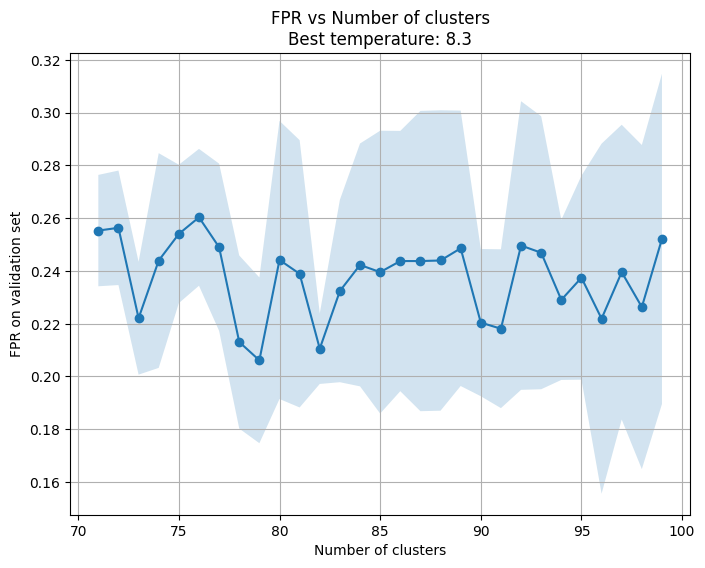

In [115]:
best_temp, ax = plot_metric_curve(
    df,
    metric="fpr",
    fixed="temperature",   # fix temperature, free axis = n_clusters
    fixed_value=None       # choose best temperature automatically (min FPR)
)
print("Chosen temperature:", best_temp)


In [116]:
import os
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple, List

def plot_metric_curve(
    df,
    metric: str,
    fixed: str = "temperature",            # "temperature" or "n_clusters"
    fixed_value: Optional[float] = None,   # if None: auto-select the best for THIS df
    min_value: Optional[float] = None,     # filter free axis (>=)
    max_value: Optional[float] = None,     # filter free axis (<=)
    metric_col_suffix: str = "_val_cross",
    std_col_suffix: str = "_val_cross_std",
    temp_col: str = "clustering.temperature",
    k_col: str = "clustering.n_clusters",
    ascending: Optional[bool] = None,      # None -> infer from metric name
    title_prefix: Optional[str] = None,
    ax: Optional[plt.Axes] = None,
    fix_tol: float = 1e-10,                # tolerance for float equality on fixed temperature
    print_duplicates: bool = False,        # print rows before raising
    label: Optional[str] = None,           # legend label for this series
) -> Tuple[float, plt.Axes]:
    """Strict plotting: raises if duplicate x remain after fixing one hyperparameter.
       Column names can be dotted or underscored (auto-resolved)."""

    import pandas as pd

    def _resolve_col(df, preferred: str, alts: Optional[List[str]] = None) -> str:
        cands = [preferred]
        if "." in preferred: cands.append(preferred.replace(".", "_"))
        if "_" in preferred: cands.append(preferred.replace("_", "."))
        if alts:
            cands += alts
            for a in list(alts):
                if "." in a: cands.append(a.replace(".", "_"))
                if "_" in a: cands.append(a.replace("_", "."))
        for c in cands:
            if c in df.columns: return c
        raise KeyError(f"None of these columns found: {cands}")

    temp_col = _resolve_col(df, temp_col, alts=["temperature","temp","clustering_temperature"])
    k_col    = _resolve_col(df,  k_col,   alts=["n_clusters","k","clustering_n_clusters"])

    mean_col = f"{metric}{metric_col_suffix}"
    std_col  = f"{metric}{std_col_suffix}"
    for c in (mean_col, std_col):
        if c not in df.columns:
            raise KeyError(f"Required metric column '{c}' not in df")

    if ascending is None:
        lower_is_better = {"fpr","aurc","err","nll","loss","brier","ece"}
        ascending = metric.lower() in lower_is_better  # True => minimize

    if fixed not in {"temperature","n_clusters"}:
        raise ValueError("`fixed` must be 'temperature' or 'n_clusters'.")

    if fixed == "temperature":
        fixed_col = temp_col; x_col = k_col
        fixed_name = "temperature"; free_name = "Number of clusters"
    else:
        fixed_col = k_col; x_col = temp_col
        fixed_name = "number of clusters"; free_name = "Temperature"

    keep = [temp_col, k_col, mean_col, std_col]
    df_clean = df[keep].dropna()

    # choose best fixed value for THIS df, if not supplied
    if fixed_value is None:
        g = df_clean.groupby(fixed_col, as_index=False)[mean_col].mean()
        if g.empty:
            raise ValueError("No data to choose a best fixed value.")
        fixed_value = g.sort_values(mean_col, ascending=ascending).iloc[0][fixed_col]

    # slice by fixed value (with tolerance for float temperatures)
    if fixed == "temperature":
        vals = df_clean[fixed_col].to_numpy()
        mask = np.isclose(vals, fixed_value, rtol=0.0, atol=fix_tol)
        df_sel = df_clean.loc[mask].copy()
    else:
        df_sel = df_clean.loc[df_clean[fixed_col] == fixed_value].copy()

    if df_sel.empty:
        raise ValueError(f"No rows after fixing {fixed_col}={fixed_value}.")

    # optional range filter on the free axis
    if min_value is not None: df_sel = df_sel[df_sel[x_col] >= min_value]
    if max_value is not None: df_sel = df_sel[df_sel[x_col] <= max_value]
    if df_sel.empty:
        raise ValueError("All rows filtered out by min_value/max_value.")

    # strict duplicate check
    vc = df_sel[x_col].value_counts().sort_index()
    dup = vc[vc > 1]
    if not dup.empty:
        if print_duplicates:
            print("Duplicate x-values:", dict(dup))
            with pd.option_context("display.width", 160):
                print(df_sel[df_sel[x_col].isin(dup.index)]
                      .sort_values([x_col, temp_col, k_col, mean_col])
                      .to_string(index=False))
        raise ValueError(
            f"Duplicate x-values for {x_col} after fixing {fixed_col}={fixed_value}: {dict(dup)}"
        )

    # plot
    df_plot = df_sel.sort_values(x_col)
    x = df_plot[x_col].to_numpy()
    y = df_plot[mean_col].to_numpy()
    s = np.clip(df_plot[std_col].to_numpy(), 0.0, None)

    if np.any(~np.isfinite(x) | ~np.isfinite(y) | ~np.isfinite(s)):
        raise ValueError("Non-finite values in x/mean/std.")

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    line, = ax.plot(x, y, marker="o", label=label)
    ax.fill_between(x, y - s, y + s, alpha=0.20, linewidth=0)

    if title_prefix is None:
        title_prefix = f"{metric.upper()} vs {free_name}"
    ax.set_title(title_prefix)
    ax.set_xlabel(free_name)
    ax.set_ylabel(f"{metric.upper()} on validation set")
    ax.grid(True)

    return (float(fixed_value) if isinstance(fixed_value, (int,float,np.floating)) else fixed_value), ax


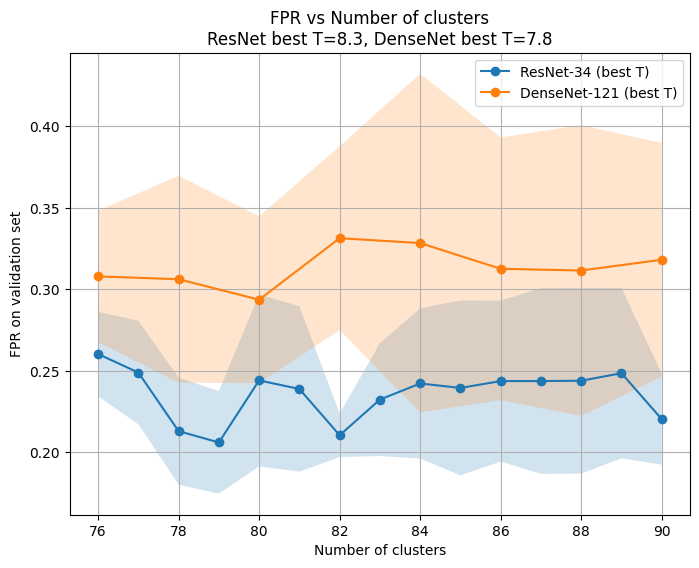

In [122]:
# --- load each model's table ---
df_resnet34 = read_table(
    data_name="cifar10", model_name="resnet34", method_name="clustering",
    r=2, seed_split=9, n_epochs=1, transform="test",
    space="probits", n_folds=3, clustering_name="soft-kmeans", hyperparam=True
)

df_densenet121 = read_table(
    data_name="cifar10", model_name="densenet121", method_name="clustering",
    r=2, seed_split=9, n_epochs=1, transform="test",
    space="probits", n_folds=3, clustering_name="soft-kmeans", hyperparam=True
)

# --- plot both on the same axes ---
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))

# Choose what to fix (temperature) and the metric to optimize
# Each model selects its own best temperature unless you provide fixed_value
min_value = 76
max_value = 90
best_t_resnet, ax = plot_metric_curve(
    df_resnet34, metric="fpr", fixed="temperature",
    min_value=min_value, max_value=max_value,          # optional: restrict K range
    label="ResNet-34 (best T)",
    ax=ax, print_duplicates=True
)

best_t_dense, _ = plot_metric_curve(
    df_densenet121, metric="fpr", fixed="temperature",
    min_value=min_value, max_value=max_value,
    label="DenseNet-121 (best T)",
    ax=ax, print_duplicates=True
)

ax.set_title(f"FPR vs Number of clusters\nResNet best T={best_t_resnet:.3g}, DenseNet best T={best_t_dense:.3g}")
ax.legend()
plt.show()


In [16]:
cols = [col for col in df.columns if col.startswith(f'{method_name}_')]
df[cols + ["fpr_val_cross", "aurc_val_cross", "roc_auc_val_cross"]].sort_values("fpr_val_cross").head(30)

,clustering_name,clustering_distance,clustering_n_clusters,clustering_reorder_embs,clustering_seed,clustering_alpha,clustering_init_scheme,clustering_n_init,clustering_space,clustering_cov_type,clustering_temperature,clustering_normalize_gini,clustering_reduction_name,clustering_reduction_dim,clustering_reduction_n_neighbors,clustering_reduction_seed,fpr_val_cross,aurc_val_cross,roc_auc_val_cross
18,soft-kmeans,NaN,108,True,0,0.05,kmeans,5,probits,diag,5.2,False,NaN,NaN,NaN,NaN,0.242274,0.173501,0.922946
37,soft-kmeans,NaN,108,True,0,0.05,kmeans,5,probits,diag,5.4,False,NaN,NaN,NaN,NaN,0.256539,0.168997,0.916391
85,soft-kmeans,NaN,90,True,0,0.05,kmeans,5,probits,diag,6.0,False,NaN,NaN,NaN,NaN,0.260599,0.172627,0.919922
308,soft-kmeans,NaN,80,True,0,0.05,kmeans,5,probits,diag,8.4,False,NaN,NaN,NaN,NaN,0.266759,0.169228,0.915412
306,soft-kmeans,NaN,76,True,0,0.05,kmeans,5,probits,diag,8.4,False,NaN,NaN,NaN,NaN,0.268029,0.167900,0.916659
279,soft-kmeans,NaN,98,True,0,0.05,kmeans,5,probits,diag,8.0,False,NaN,NaN,NaN,NaN,0.270591,0.169150,0.915751
240,soft-kmeans,NaN,96,True,0,0.05,kmeans,5,probits,diag,7.6,False,NaN,NaN,NaN,NaN,0.273995,0.171511,0.914035
90,soft-kmeans,NaN,100,True,0,0.05,kmeans,5,probits,diag,6.0,False,NaN,NaN,NaN,NaN,0.274637,0.168066,0.914294
118,soft-kmeans,NaN,80,True,0,0.05,kmeans,5,probits,diag,6.4,False,NaN,NaN,NaN,NaN,0.274861,0.166691,0.914994
91,soft-kmeans,NaN,102,True,0,0.05,kmeans,5,probits,diag,6.0,False,NaN,NaN,NaN,NaN,0.276340,0.169521,0.915148


In [17]:
cols = [col for col in df2.columns if col.startswith(f'{method_name}_')]
df2[cols + ["fpr_val_cross", "aurc_val_cross", "roc_auc_val_cross"]].sort_values("fpr_val_cross").head(30)

,clustering_name,clustering_distance,clustering_n_clusters,clustering_reorder_embs,clustering_seed,clustering_alpha,clustering_init_scheme,clustering_n_init,clustering_space,clustering_cov_type,clustering_temperature,clustering_pred_weight,clustering_normalize_gini,clustering_reduction_name,clustering_reduction_dim,clustering_reduction_n_neighbors,clustering_reduction_seed,fpr_val_cross,aurc_val_cross,roc_auc_val_cross
103,soft-kmeans,NaN,96,True,0,0.05,kmeans,5,probits,diag,4.9,0.0000,False,NaN,NaN,NaN,NaN,0.269079,0.172908,0.920844
123,soft-kmeans,NaN,96,True,0,0.05,kmeans,5,probits,diag,4.9,0.0010,False,NaN,NaN,NaN,NaN,0.270149,0.170992,0.917316
130,soft-kmeans,NaN,90,True,0,0.05,kmeans,5,probits,diag,4.9,0.0015,False,NaN,NaN,NaN,NaN,0.271623,0.173643,0.917955
250,soft-kmeans,NaN,90,True,0,0.05,kmeans,5,probits,diag,5.1,0.0025,False,NaN,NaN,NaN,NaN,0.279544,0.169323,0.917740
478,soft-kmeans,NaN,106,True,0,0.05,kmeans,5,probits,diag,5.5,0.0035,False,NaN,NaN,NaN,NaN,0.282270,0.168381,0.915296
586,soft-kmeans,NaN,102,True,0,0.05,kmeans,5,probits,diag,5.7,0.0040,False,NaN,NaN,NaN,NaN,0.283128,0.174024,0.921358
62,soft-kmeans,NaN,94,True,0,0.05,kmeans,5,probits,diag,4.7,0.0030,False,NaN,NaN,NaN,NaN,0.284610,0.172039,0.919957
829,soft-kmeans,NaN,108,True,0,0.05,kmeans,5,probits,diag,6.3,0.0010,False,NaN,NaN,NaN,NaN,0.285453,0.173072,0.920017
81,soft-kmeans,NaN,92,True,0,0.05,kmeans,5,probits,diag,4.7,0.0040,False,NaN,NaN,NaN,NaN,0.286366,0.172782,0.922238
651,soft-kmeans,NaN,92,True,0,0.05,kmeans,5,probits,diag,5.9,0.0025,False,NaN,NaN,NaN,NaN,0.287600,0.171401,0.915154


In [37]:
df2 = pd.read_csv("../../results/cifar100_densenet121_r-2_seed-split-9/transform-test_n-epoch1_n-folds10_probits_predweight_clustering/all_results.csv")
df2

,seed,method_name,data_name,data_n_classes,data_dim,data_n_samples,data_seed,data_seed_split,data_n_splits,data_n_epochs,...,aupr_err_train,aupr_success_train,fpr_val,tpr_val,thr_val,roc_auc_val,model_acc_val,aurc_val,aupr_err_val,aupr_success_val
0,1,clustering,cifar100,100,3072,10000,NaN,9,10,1,...,0.666285,0.946512,0.488643,0.951613,0.170122,0.848095,0.2604,0.478346,0.603003,0.938638


In [35]:
get_grid_search(df2).head(20)

,clustering_name,clustering_distance,clustering_n_clusters,clustering_reorder_embs,clustering_seed,clustering_alpha,clustering_init_scheme,clustering_n_init,clustering_space,clustering_cov_type,clustering_temperature,clustering_pred_weight,clustering_normalize_gini,clustering_reduction_name,clustering_reduction_dim,clustering_reduction_n_neighbors,clustering_reduction_seed
0,soft-kmeans,NaN,80,True,0,0.05,kmeans,5,probits,diag,1.2,0.0000,False,NaN,NaN,NaN,NaN
1,soft-kmeans,NaN,80,True,0,0.05,kmeans,5,probits,diag,1.2,0.0005,False,NaN,NaN,NaN,NaN
2,soft-kmeans,NaN,80,True,0,0.05,kmeans,5,probits,diag,1.2,0.0010,False,NaN,NaN,NaN,NaN
3,soft-kmeans,NaN,80,True,0,0.05,kmeans,5,probits,diag,1.2,0.0015,False,NaN,NaN,NaN,NaN
4,soft-kmeans,NaN,80,True,0,0.05,kmeans,5,probits,diag,1.2,0.0020,False,NaN,NaN,NaN,NaN
5,soft-kmeans,NaN,80,True,0,0.05,kmeans,5,probits,diag,1.2,0.0025,False,NaN,NaN,NaN,NaN
6,soft-kmeans,NaN,80,True,0,0.05,kmeans,5,probits,diag,1.2,0.0030,False,NaN,NaN,NaN,NaN
7,soft-kmeans,NaN,80,True,0,0.05,kmeans,5,probits,diag,1.2,0.0035,False,NaN,NaN,NaN,NaN
8,soft-kmeans,NaN,80,True,0,0.05,kmeans,5,probits,diag,1.2,0.0040,False,NaN,NaN,NaN,NaN
9,soft-kmeans,NaN,80,True,0,0.05,kmeans,5,probits,diag,1.2,0.0045,False,NaN,NaN,NaN,NaN


# Doctor

## CiFAR10

In [137]:
data_name = "imagenet"
r= 2
model_name = "timm_vit_base16"  # resnet34, densenet121, vit_tiny16, vit_base16, mlp_synth_dim-10_classes-7
seed_split = 9
transform = "test"
method_name = "gini"
# n_epochs = 1
# space = "logits"

df = read_table(
    data_name=data_name,
    model_name=model_name,
    method_name=method_name,
    r=r,
    seed_split=seed_split,
    # n_epochs=n_epochs,
    transform=transform,
    # space=space,
    hyperparam=False
)


print("Df shape", df.shape)
df.tail(20).sort_values("fpr_train")


Df shape (1, 84)


,seed,method_name,data_name,data_n_classes,data_dim,data_n_samples,data_seed,data_seed_split,data_n_splits,data_n_epochs,...,aupr_err_train,aupr_success_train,fpr_val,tpr_val,thr_val,roc_auc_val,model_acc_val,aurc_val,aupr_err_val,aupr_success_val
0,1,gini,imagenet,1000,3072,10000,NaN,9,10,1,...,0.591199,0.968255,0.422994,0.950154,0.020529,0.876703,0.18136,0.390357,0.59506,0.969015


In [138]:
cols = [col for col in df.columns if col.startswith(f'{method_name}_')]
df[cols + ["fpr_train", "aurc_train", "roc_auc_train"]].sort_values("fpr_train").head(30)

,gini_temperature,gini_normalize_gini,gini_magnitude,fpr_train,aurc_train,roc_auc_train
0,0.9,True,0.0,0.424634,0.391182,0.875581


In [134]:
expe_folder = f"../../results/{data_name}_{model_name}_r-{r}_seed-split-{seed_split}/transform-{transform}_normalized-False_{method_name}" #
if True:
    df = pd.read_csv(os.path.join(expe_folder, "all_results.csv")) # hyperparams_results
df.head()

,seed,method_name,data_name,data_n_classes,data_dim,data_n_samples,data_seed,data_seed_split,data_n_splits,data_n_epochs,...,max_proba_temperature.1,metric_learning_lbd.1,metric_learning_magnitude.1,metric_learning_temperature.1,model_acc_val,model_model_seed.1,model_name.1,roc_auc_val,thr_val,tpr_val
0,1,gini,imagenet,1000,3072,10000,NaN,9,3,1,...,NaN,NaN,NaN,NaN,0.243,1,timm_vit_tiny16,0.86496,0.151906,0.950123


In [105]:
get_grid_search(df).tail(20)

,gini_temperature,gini_normalize_gini,gini_magnitude
29,1.1,True,0.002
30,1.1,True,0.004
31,1.1,True,0.006
32,1.1,True,0.008
33,1.1,True,0.010
34,1.1,True,0.012
35,1.2,True,0.000
36,1.2,True,0.002
37,1.2,True,0.004
38,1.2,True,0.006


# Max_Proba

## CIFAR10

### Densenet121

In [138]:
data_name = "cifar10"
r= 2
model_name = "densenet121"
seed_split = 9
transform = "test"
method_name = "max_proba"
# n_epochs = 1
# space = "logits"

df = read_table(
    data_name=data_name,
    model_name=model_name,
    method_name=method_name,
    r=r,
    seed_split=seed_split,
    # n_epochs=n_epochs,
    transform=transform,
    # space=space
)


print("Df shape", df.shape)
df.tail(20).sort_values("fpr_train")


Df shape (49, 67)


,seed,method_name,data_name,data_n_classes,data_dim,data_n_samples,data_seed,data_seed_split,data_n_splits,data_n_epochs,...,fpr_train,tpr_train,thr_train,roc_auc_train,model_acc_train,aurc_train,aupr_err_train,aupr_success_train,file_num,source_file
35,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,0.342559,0.950495,-0.996948,0.912666,0.0606,0.174491,0.433600,0.991396,0,hyperparams_results.csv
42,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,0.342559,0.950495,-0.994770,0.912342,0.0606,0.174549,0.434547,0.991314,0,hyperparams_results.csv
43,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,0.457739,0.950495,-0.998718,0.896464,0.0606,0.170244,0.411918,0.989316,0,hyperparams_results.csv
36,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,0.461145,0.950495,-0.999364,0.897356,0.0606,0.170234,0.411108,0.989440,0,hyperparams_results.csv
29,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,0.467320,0.950495,-0.999723,0.898171,0.0606,0.170348,0.411319,0.989533,0,hyperparams_results.csv
30,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,0.526080,0.950495,-0.999908,0.878576,0.0606,0.164412,0.380471,0.987355,0,hyperparams_results.csv
37,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,0.530126,0.950495,-0.999777,0.877092,0.0606,0.163969,0.378180,0.987262,0,hyperparams_results.csv
44,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,0.540984,0.950495,-0.999542,0.875454,0.0606,0.163633,0.376857,0.987044,0,hyperparams_results.csv
31,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,0.622099,0.950495,-0.999971,0.857389,0.0606,0.157909,0.348402,0.985394,0,hyperparams_results.csv
38,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,0.623590,0.950495,-0.999921,0.855120,0.0606,0.157306,0.345734,0.985050,0,hyperparams_results.csv


In [42]:
cols = [col for col in df.columns if col.startswith(f'{method_name}_')]
df[cols + ["fpr_train", "aurc_train", "roc_auc_train"]].sort_values("aurc_train").head(20)

,max_proba_temperature,max_proba_magnitude,fpr_train,aurc_train,roc_auc_train
48,1.3,0.012,0.723653,0.135440,0.798024
41,1.2,0.012,0.720460,0.136462,0.801344
34,1.1,0.012,0.715137,0.137446,0.804511
27,1.0,0.012,0.708537,0.138522,0.808327
20,0.9,0.012,0.745582,0.139387,0.812208
13,0.8,0.012,1.000000,0.141020,0.812814
47,1.3,0.010,0.705344,0.141813,0.812959
40,1.2,0.010,0.692570,0.142876,0.816323
33,1.1,0.010,0.692996,0.143697,0.819391
26,1.0,0.010,0.687460,0.144694,0.822503


In [10]:
get_grid_search(df)

,max_proba_temperature,max_proba_magnitude
0,0.7,0.000
1,0.7,0.002
2,0.7,0.004
3,0.7,0.006
4,0.7,0.008
5,0.7,0.010
6,0.7,0.012
7,0.8,0.000
8,0.8,0.002
9,0.8,0.004


### Resnet34

In [27]:
data_name = "cifar10"
r= 2
model_name = "resnet34"
seed_split = 9
transform = "test"
method_name = "max_proba"
# n_epochs = 1
# space = "logits"

df = read_table(
    data_name=data_name,
    model_name=model_name,
    method_name=method_name,
    r=r,
    seed_split=seed_split,
    # n_epochs=n_epochs,
    transform=transform,
    # space=space
)


print("Df shape", df.shape)
df.tail(20).sort_values("fpr_train")


Df shape (49, 65)


,seed,method_name,data_name,data_n_classes,data_dim,data_n_samples,data_seed,data_seed_split,data_n_splits,data_n_epochs,...,experiment_datetime,experiment_folder,fpr_train,tpr_train,thr_train,roc_auc_train,model_acc_train,aurc_train,aupr_err_train,aupr_success_train
35,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,2025-09-13_00-59-39,bwe,0.447689,0.95,-0.998297,0.924960,0.048,0.151932,0.471511,0.994889
42,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,2025-09-13_00-59-39,bwe,0.454832,0.95,-0.996822,0.923933,0.048,0.152005,0.473936,0.994763
43,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,2025-09-13_00-59-39,bwe,0.627941,0.95,-0.997969,0.897402,0.048,0.146401,0.439222,0.991310
36,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,2025-09-13_00-59-39,bwe,0.628782,0.95,-0.998977,0.899015,0.048,0.146567,0.438895,0.991491
29,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,2025-09-13_00-59-39,bwe,0.631933,0.95,-0.999544,0.900741,0.048,0.146740,0.438595,0.991690
30,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,2025-09-13_00-59-39,bwe,0.687605,0.95,-0.999659,0.871056,0.048,0.139088,0.390269,0.988926
37,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,2025-09-13_00-59-39,bwe,0.694328,0.95,-0.999228,0.868682,0.048,0.138722,0.389234,0.988674
44,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,2025-09-13_00-59-39,bwe,0.700000,0.95,-0.998453,0.866328,0.048,0.138374,0.388450,0.988446
38,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,2025-09-13_00-59-39,bwe,0.707563,0.95,-0.999343,0.837395,0.048,0.130032,0.340612,0.986542
45,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,2025-09-13_00-59-39,bwe,0.709664,0.95,-0.998659,0.834087,0.048,0.129386,0.338161,0.986273


In [39]:
cols = [col for col in df.columns if col.startswith(f'{method_name}_')]
df[cols + ["fpr_train", "aurc_train", "roc_auc_train"]].sort_values("aurc_train").head(20)

,max_proba_temperature,max_proba_magnitude,fpr_train,aurc_train,roc_auc_train
48,1.3,0.012,0.805462,0.107763,0.758497
41,1.2,0.012,0.803782,0.108480,0.761918
34,1.1,0.012,0.801261,0.109222,0.765644
27,1.0,0.012,0.797689,0.110181,0.769869
20,0.9,0.012,0.798950,0.111142,0.774326
13,0.8,0.012,0.811134,0.112203,0.779301
47,1.3,0.010,0.782773,0.113210,0.775134
6,0.7,0.012,0.845588,0.113308,0.782454
40,1.2,0.010,0.785714,0.113983,0.778867
33,1.1,0.010,0.784454,0.114745,0.782818


In [34]:
sort_values(df, metrics=["aurc_train"]).head(20)

,max_proba_temperature,max_proba_magnitude,aurc_train
48,1.3,0.012,0.107763
41,1.2,0.012,0.108480
34,1.1,0.012,0.109222
27,1.0,0.012,0.110181
20,0.9,0.012,0.111142
13,0.8,0.012,0.112203
47,1.3,0.010,0.113210
6,0.7,0.012,0.113308
40,1.2,0.010,0.113983
33,1.1,0.010,0.114745


In [16]:
get_grid_search(df)

,max_proba_temperature,max_proba_magnitude
0,0.7,0.000
1,0.7,0.002
2,0.7,0.004
3,0.7,0.006
4,0.7,0.008
5,0.7,0.010
6,0.7,0.012
7,0.8,0.000
8,0.8,0.002
9,0.8,0.004


## CIFAR100

### Densenet121

In [70]:
data_name = "cifar10"
r= 2
model_name = "resnet34"
seed_split = 9
transform = "test"
method_name = "max_proba"
# n_epochs = 1
# space = "logits"

df = read_table(
    data_name=data_name,
    model_name=model_name,
    method_name=method_name,
    r=r,
    seed_split=seed_split,
    # n_epochs=n_epochs,
    transform=transform,
    # space=space,
    hyperparam = False
)


print("Df shape", df.shape)
df.tail(20).sort_values("fpr_train")


Df shape (1, 73)


,seed,method_name,data_name,data_n_classes,data_dim,data_n_samples,data_seed,data_seed_split,data_n_splits,data_n_epochs,...,aupr_err_train,aupr_success_train,fpr_val,tpr_val,thr_val,roc_auc_val,model_acc_val,aurc_val,aupr_err_val,aupr_success_val
0,1,max_proba,cifar10,10,3072,10000,NaN,9,3,1,...,0.462814,0.995489,0.270327,0.951754,-0.99999,0.925663,0.0456,0.139683,0.394693,0.995609


In [66]:
get_grid_search(df)["max_proba_magnitude"].value_counts()

max_proba_magnitude
0.000    40
0.001    40
0.002    40
0.003    40
0.004    40
0.005    40
0.006    40
0.007    40
0.008    40
0.009    40
0.010    40
0.011    40
0.012    40
0.013    40
0.014    40
0.015    40
0.016    40
0.017    40
0.018    40
0.019    40
Name: count, dtype: int64